In [26]:

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import sys
from pathlib import Path
from torchvision.datasets.utils import download_url
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions import graph_print_analysis as gp_tool
    from train_mnist_with_network import HBModel_MNIST as hbm
    from functions.Hilbert_computation import hilbert_computation as hbc

finally:
    sys.path = _old_sys_path


In [27]:
Output_Dir = Path.cwd().parent.parent / "experiments" / "MNIST_network"
num_epochs = 2
lr = 1e-2
if_decay = True
batch_sizes = {16, 32, 64, 128, 256, 512, 1024}
batch_size=256
steps = {200, 400, 800, 1200, 1600, 2000}
step=100
lrs={1e-4,1e-3, 1e-2, 1e-1}
decays={0, 1e-4, 1e-3, 1e-2}
if_regularize=True

In [28]:
##Test file
num_layers=5
model_name=f'mnist_hilbert_bs{batch_size}_lr{lr}_decay{if_decay}_reg{if_regularize}_layers{num_layers}_steps{500}'

testresult=hbm.train_mnist_with_hilbert(
    number_of_layers=num_layers,
    max_steps=2000,
    batch_size=4096,
    lr=lr,
    if_regularize=if_regularize,
    if_decay=if_decay,
    save_path=Output_Dir/f"{model_name}_traj.pt",
    if_record_test=True,
    check_distance=100,)



In [29]:
param_traj=testresult['param_traj']
loss_traj=testresult['loss_traj']
w_final=param_traj[-1]

In [58]:
import matplotlib.pyplot as plt
import numpy as np
w_star=param_traj[-1]
H_to_final,max_indices,min_indices=hbc.compute_hilbert_to_w_star(param_traj,w_star=w_star,ifmask=False,threshold=1e-8)
H_to_final1=H_to_final


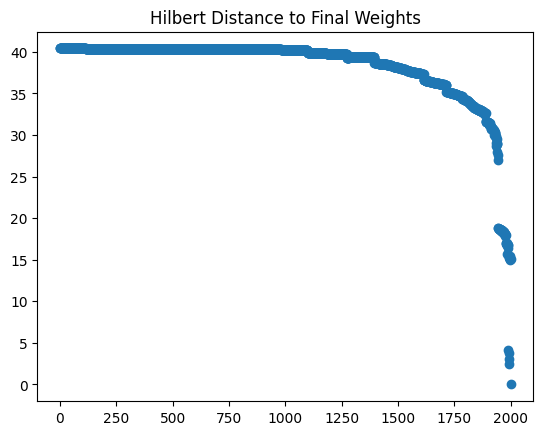

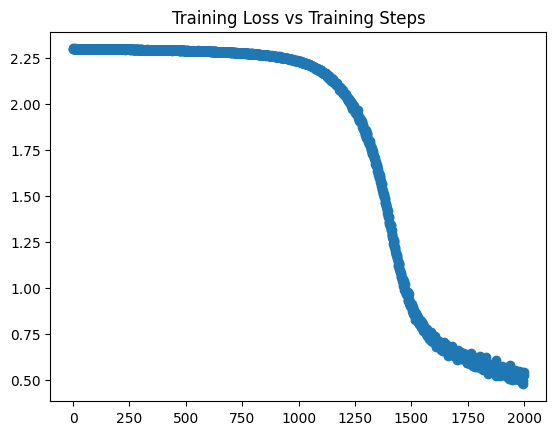

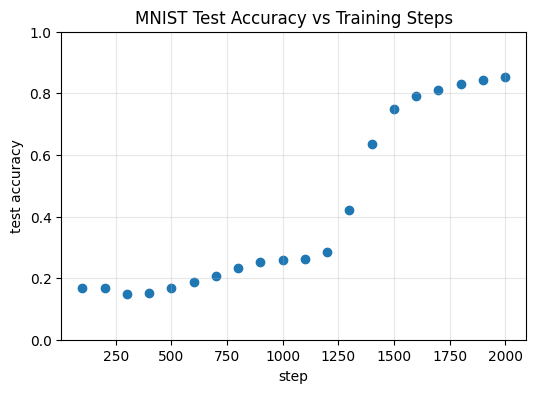

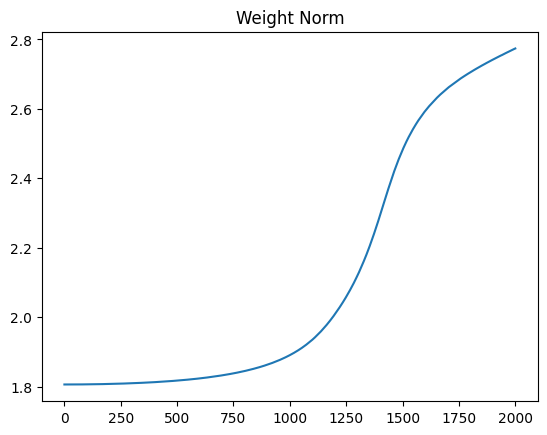

In [103]:
plt.scatter(range(len(H_to_final1)),H_to_final1)
plt.title("Hilbert Distance to Final Weights")
plt.show()
plt.scatter(range(len(loss_traj)),loss_traj)
plt.title("Training Loss vs Training Steps")
plt.show()
traj = accuracy_traj['acc_traj']          # list of dicts
steps = [d['step'] for d in traj]
accs  = [d['acc']  for d in traj]

plt.figure(figsize=(6,4))
plt.scatter(steps, accs)                  # scatter
plt.xlabel("step")
plt.ylabel("test accuracy")
plt.title("MNIST Test Accuracy vs Training Steps")
plt.ylim(0, 1)                            # 可选：MNIST accuracy范围更直观
plt.grid(True, alpha=0.3)
plt.show()
w_norm=np.linalg.norm(np.array(param_traj),axis=1)
plt.plot(range(len(w_norm)),w_norm)
plt.title("Weight Norm")
plt.show()


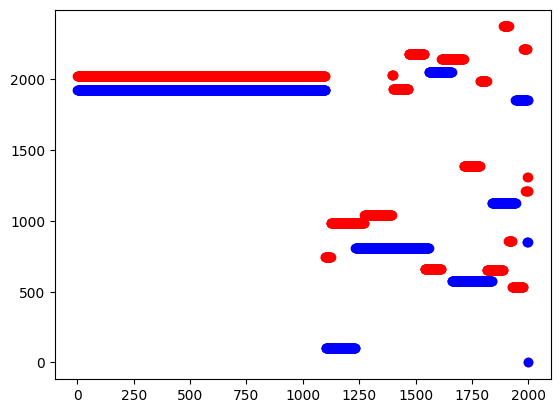

In [60]:
plt.scatter(range(len(max_indices)),max_indices,color='r')
plt.scatter(range(len(min_indices)),min_indices,color='b')
plt.show()

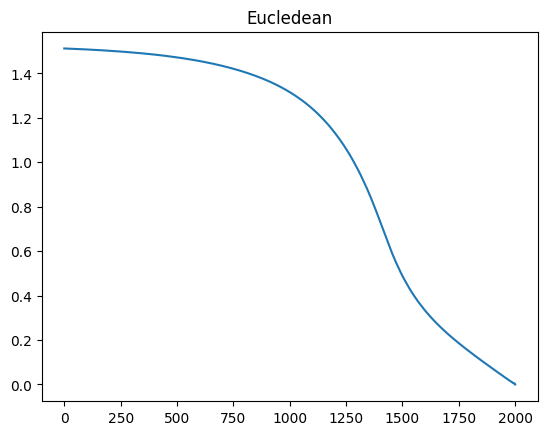

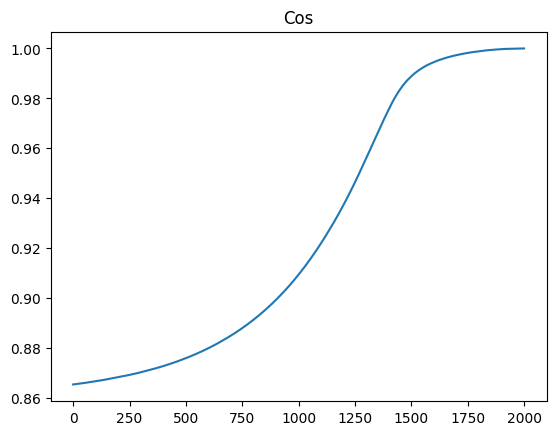

In [105]:

l2_to_final=np.linalg.norm(np.array(param_traj)-param_traj[-1].cpu().numpy(),axis=1)

plt.plot(range(len(l2_to_final)),l2_to_final)
plt.title("Eucledean")

plt.show()

cos_to_final=param_traj@w_star.cpu().numpy()/(np.linalg.norm(np.array(param_traj),axis=1)*np.linalg.norm(w_star.cpu().numpy()))
plt.plot(range(len(cos_to_final)),cos_to_final)
plt.title("Cos")
plt.show()


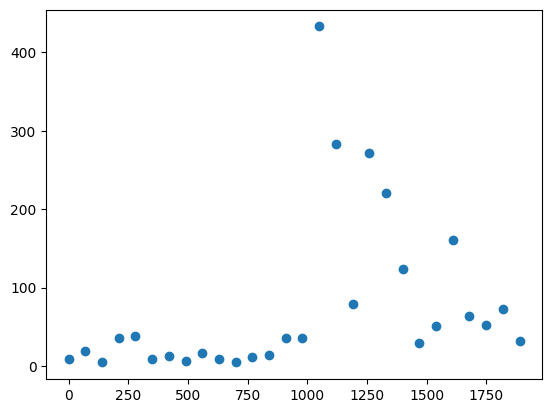

In [101]:
_old_sys_path = sys.path.copy()
try:
    project_root = Path.cwd().parent
    sys.path.insert(0, str(Path.cwd().resolve().parents[1]))
    from functions.Hilbert_computation import distance_func as hb_distance

finally:
    sys.path = _old_sys_path
special_distances=[]
gap=70
interval=7
for i in range(0,len(param_traj)-6-gap,gap):
    w_targets=param_traj[i+gap:i+gap+interval]
    w_target=torch.mean(torch.stack(w_targets),dim=0)
    w_refers=param_traj[i:i+interval]
    w_refer=torch.mean(torch.stack(w_refers),dim=0)
    ratio=w_target.cpu().numpy()/w_refer.cpu().numpy()
    max_ratio=np.max(ratio)
    min_ratio=np.min(ratio)
    special_distances.append(max_ratio-min_ratio)
steps=np.array(range(len(special_distances)))*gap
plt.scatter(steps,special_distances)
plt.show()


In [63]:
# from sklearn.decomposition import PCA
# trajectory = param_traj
# w_traj = np.array(trajectory[600:950])    # shape: (T+1, D)
# w_final = w_star.cpu().numpy()  # shape: (D,
# R = w_traj - w_final          # shape: (T+1, D)
# pca = PCA(n_components=1)
# pca.fit(R)
# v = pca.components_[0]       # 主方向，单位向量

# a = R @ v                    # shape: (T+1,)
# plt.plot(range(600,950),a)
# plt.show()

In [43]:
# HTF,HTB,HTI=analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps'])

In [44]:

# for res in results:
#     HTF=[]
#     HTB=[]
#     HTI=[]
#     hilbert_analysis_result=analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps'])
#     HTF.append(hilbert_analysis_result["hilbert_to_finals"])
#     HTB.append(hilbert_analysis_result["hilbert_to_betweens"])
#     HTI.append(hilbert_analysis_result["hilbert_to_inits"])
#     torch.save({'HTF':HTF,'HTB':HTB,'HTI':HTI},f'Hilbert_bs{res["batch_size"]}_lr{res["lr"]}_{res["epochs_or_steps"]}.pt')
    

In [45]:
# res=train_mnist_with_hilbert(batch_size=32,lr=lr,if_regularize=if_regularize,max_steps=steps,if_decay=if_decay
#                             #  ,loss_type="huber"
#                              )

In [46]:
# res=gp_tool.analysis(param_traj=res['param_traj'],output_log=res['output_log'],batch_size=res['batch_size'],lr=res['lr'],num_epochs=res['epochs_or_steps']
#                     #  ,path='./huber_loss_results/'
#                      )
#     HTF=[]
#     HTB=[]
#     HTI=[]